
# Inversion with structural constraints

In [8]:
%matplotlib widget

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import os

First we load the data and the interface

In [10]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line02/ball_grad_A", exist_ok=True)

filename = r'data\line02\og_fromtomsnotes_mytopo\Gradient XL_A_1-2018-06-13-143156.dat'
data = ert.load(filename)
print(data)

03/03/26 - 17:35:09 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 81 data: 1478, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


In [11]:
xs = np.array([s.x() for s in data.sensors()])  # an array of all elec x-positions along line

data_min = xs.min(); data_max = xs.max()

print(data_min, data_max)

0.0 240.0


adding "topo = topo[np.argsort(topo[:,0])]"  to deal w negative vals


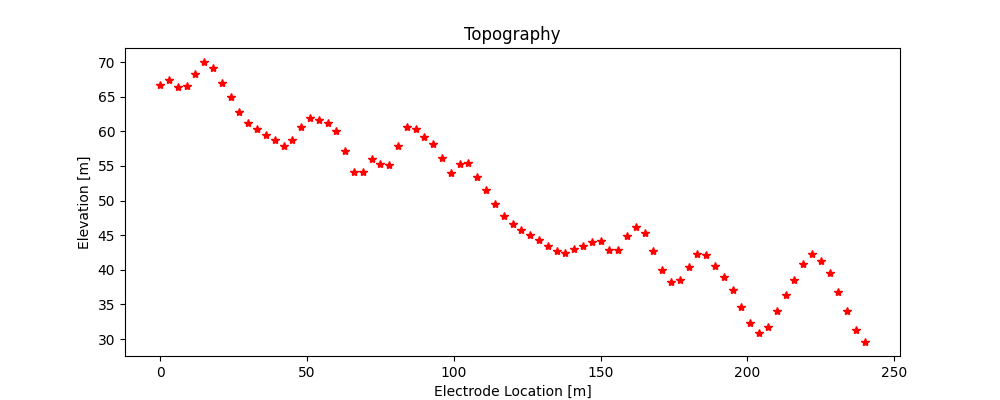

In [12]:
topo = []

topo_file = r'data\line02\og_fromtomsnotes_mytopo\line02_mytopo.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

x_elec = pg.x(data)  # get x pos of all electrodes
z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))

# print(f'x elec: {x_elec}')
# print(f'topo[:,0]: {topo[:,0]}')
# print(f'topo[:,1]: {topo[:,1]}')


# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# print(f'z interp: {z_interp}')

# set electrode positions in data
data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# plot to check
fig, ax = plt.subplots(figsize=(10,4)) 
ax.plot(x_elec, z_interp, 'r*')
ax.set_xlabel('Electrode Location [m]')
ax.set_ylabel('Elevation [m]')
ax.set_title('Topography')

plt.show()

K should convert measured resistance from the field to true resistivity.
- Analytical: assumes flat ground and ideal geometry, so less accurate.
- Numerical: solves with PDE and uses real electrode positions and topography.

In [13]:
# topo= pg.PosVector(topo)  # turn from array into pygimli pos vector

k0 = ert.createGeometricFactors(data)  # analytical; assumes simple geometry
data['k'] = ert.createGeometricFactors(data, numerical=True)  # numerical; solves forward PDE

03/03/26 - 17:35:10 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 8): C:\Users\sydne\AppData\Roaming\pygimli\Cache\17882742636016452856
03/03/26 - 17:35:10 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (7.3s x 8): C:\Users\sydne\AppData\Roaming\pygimli\Cache\11198770962024468645


Now we shall observe the topography effect, i.e the ratio between
the numerically computed geometry factor and the analytical formula after
Rücker et al. (2006). We display it using a colormap with neutral white.

from chat: "Topographic effect on resistivity
- ~1: topo has little effect
- topo > 1: ignoring topo overestimates resistivity
- topo < 1: ignoring topo underestimates resistivity"

bwr colormap directory:
- blue: high numerical k
- red: high analytical k
- white: same

Pseudo-depth: sensitivity location.
- DD: dipole dipole.
- Numbers: electrode spacing levels. 
    - Current: controls how deep the current penetrates (A-B)
    - Potential: controls voltage sensitivity (M-N).
- ex. DD2-3:
    - current dipole spacing: 2 electrodes.
    - potential dipole spacing: 3 electrodes. 

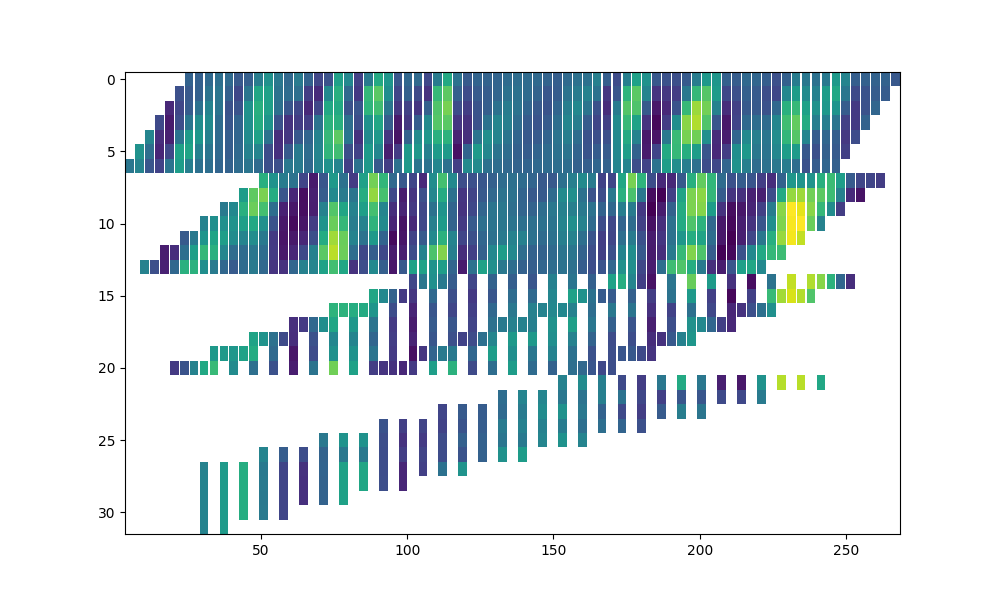

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
_ = ert.showData(data, 
                 vals=k0/ data['k'],  # quantifies the topography effect
                 ax=ax,
                 label='Topography effect', xlabel='Distance [m]', ylabel='Pseudo-depth',
                 cMin=2/3, cMax=3/2,  # color limits
                 logScale=True, 
                 cMap="bwr"  # blue-white-red colormap
)

ax.set_title('Topography Effect on Data');

fig.savefig(r"figures/line02/ball_grad_A/1topo_effect_on_data.png", dpi=300, bbox_inches='tight')


If the topography effect on data looks strange (ie. no color bar, axes titles) just rerun and it'll work!!!


We can now compute the apparent resistivity and display it, once with the
wrong analytical formula and once with the numerical values.

 Min: 21.985891235363546, Max: 4214.937900169664


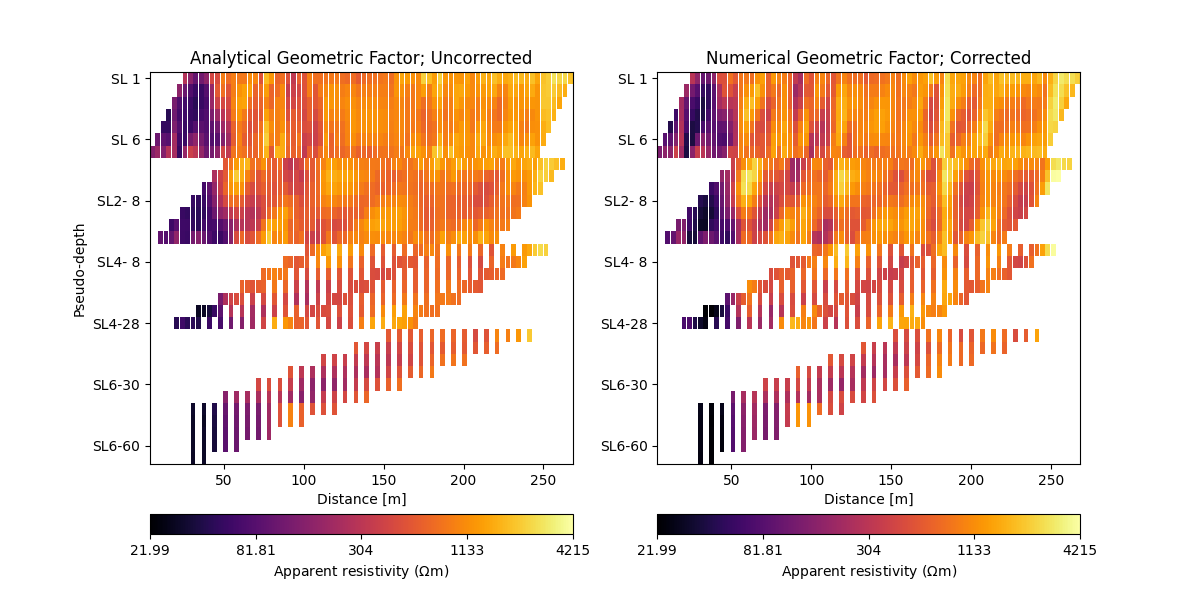

In [15]:
data['rhoa'] = data['r'] * data['k']  # uses numerical k; converts measured resistances to apparent resist

# edit impossible negative or zero values
data['rhoa'][data['rhoa'] <= 0] = 1e-6

cmin = pg.min(data['rhoa'])
cmax = pg.max(data['rhoa'])
print(f' Min: {pg.min(data["rhoa"])}, Max: {pg.max(data["rhoa"])}')

kw = dict(cMin=cmin, cMax=cmax)  # storing key/value pairs for colour scale
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

data.show(data['r']*k0, ax=ax[0], **kw, cMap='inferno', 
          xlabel='Distance [m]', ylabel='Pseudo-depth');  # uses analytical k so assumes flat ground

data.show(ax=ax[1], **kw, cMap='inferno',
          xlabel='Distance [m]')  # uses numerical k so adds topo

ax[0].set_title('Analytical Geometric Factor; Uncorrected')  # analytical
ax[1].set_title('Numerical Geometric Factor; Corrected');  # numerical 

fig.savefig(r"figures/line02/ball_grad_A/2uncorrected_vs_corrected_geometric.png", dpi=300, bbox_inches='tight')

We estimate an error and do a normal inversion using the ERT manager.
As we expect more or less layered structures, we choose a vertical
weighting factor for the regularization of 0.5.




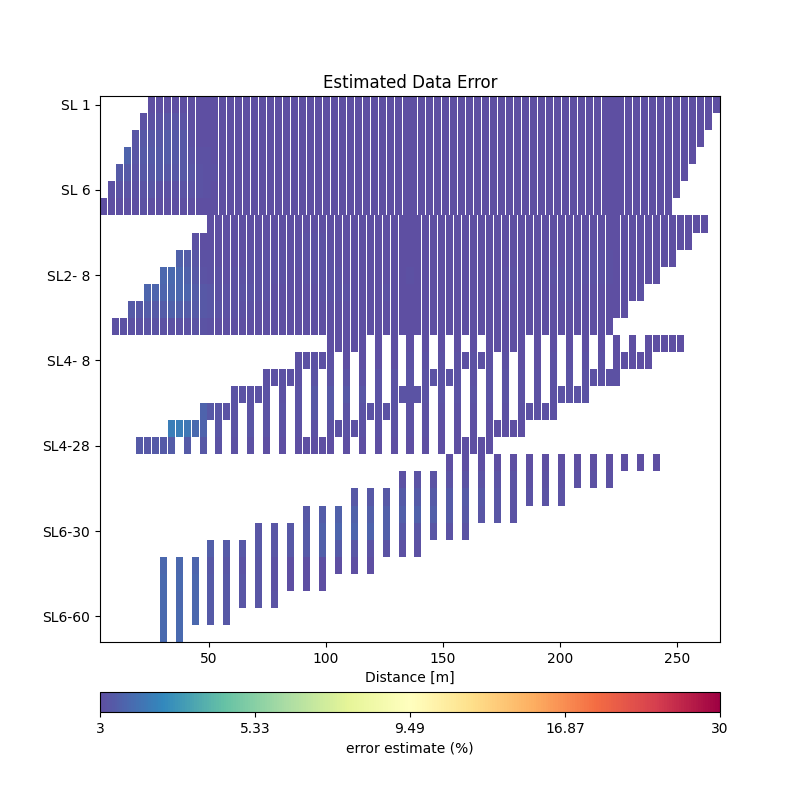

In [16]:
data.estimateError(relativeError=0.03, absoluteUError=5e-5)

fig, ax = plt.subplots(figsize=(8,8))
_ = data.show( data['err']*100, ax=ax,
    label='error estimate (%)', xlabel='Distance [m]',
    cMin=3, cMax=30)

ax.set_title('Estimated Data Error');

fig.savefig(r"figures/line02/ball_grad_A/3est_data_error.png", dpi=300, bbox_inches='tight')

mesh moment!!!!111!!!!!!

**area**: range is 0.1-10, with 2-5 a regular range

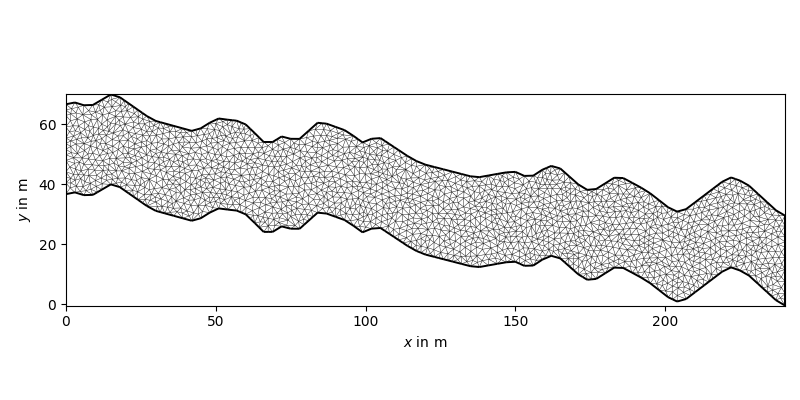

In [17]:
depth = 30  # thickness below surface 

surface = [[x, z] for x, z in zip(x_elec, z_interp)]

bottom = [[x, z - depth] for x, z in zip(reversed(x_elec), reversed(z_interp))]

# create closed polygon
polygon_points = surface + bottom

geom = mt.createPolygon(polygon_points, isClosed=True)

# create triangular mesh inside polygon
mesh = mt.createMesh(geom, quality=25, area=3)  # area controls cell size
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

pg.show(mesh, ax=ax, showMesh=True)
fig.savefig(r'figures/line02/ball_grad_A/4meshball.png', dpi=300, bbox_inches='tight')

> Now the data have all necessary fields ('rhoa', 'err' and 'k') so we can run
the inversion!! First we run this bad boy so we can figure out how we would like to constrain...

From chat:

**lam**: controls smoothness [1 – 50]
- higher → smoother, less structure
- lower → sharper, more detail (risk of noise)

**paraDX**: horizontal cell size (m) [0.25 – 1 × electrode spacing]
- smaller → higher resolution
- larger → faster, smoother
- *note*: don’t go smaller than electrode spacing

**paraMaxCellSize**: max cell size at depth and controls mesh coarsening downward [5 – 20]

**paraDepth**: max inversion depth (m) [0.2 – 0.3 × line length]

**quality**: data quality [10 - 40]

03/03/26 - 17:35:15 - pyGIMLi - INFO - Found 1 regions.
03/03/26 - 17:35:15 - pyGIMLi - INFO - Creating forward mesh from region infos.
03/03/26 - 17:35:15 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas\pygimex\ert\extra_files\line02


03/03/26 - 17:35:16 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 7654 Cells: 14836 Boundaries: 11362
03/03/26 - 17:35:16 - pyGIMLi - INFO - Use median(data values)=697.9487376121358
03/03/26 - 17:35:16 - pyGIMLi - INFO - Created startmodel from forward operator:3709, min/max=697.948738/697.948738
03/03/26 - 17:35:16 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001F0FFCE8EA0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 21.99/4215
min/max (error): 3%/3.64%
min/max (start model): 698/698
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 1644.50
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  441.35 (dPhi = 72.56%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   83.79 (dPhi = 79.72%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   39.41 (dPhi = 50.24%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =   21.02 (dPhi = 39.32%) lam: 10.0
---------------------------------------------------

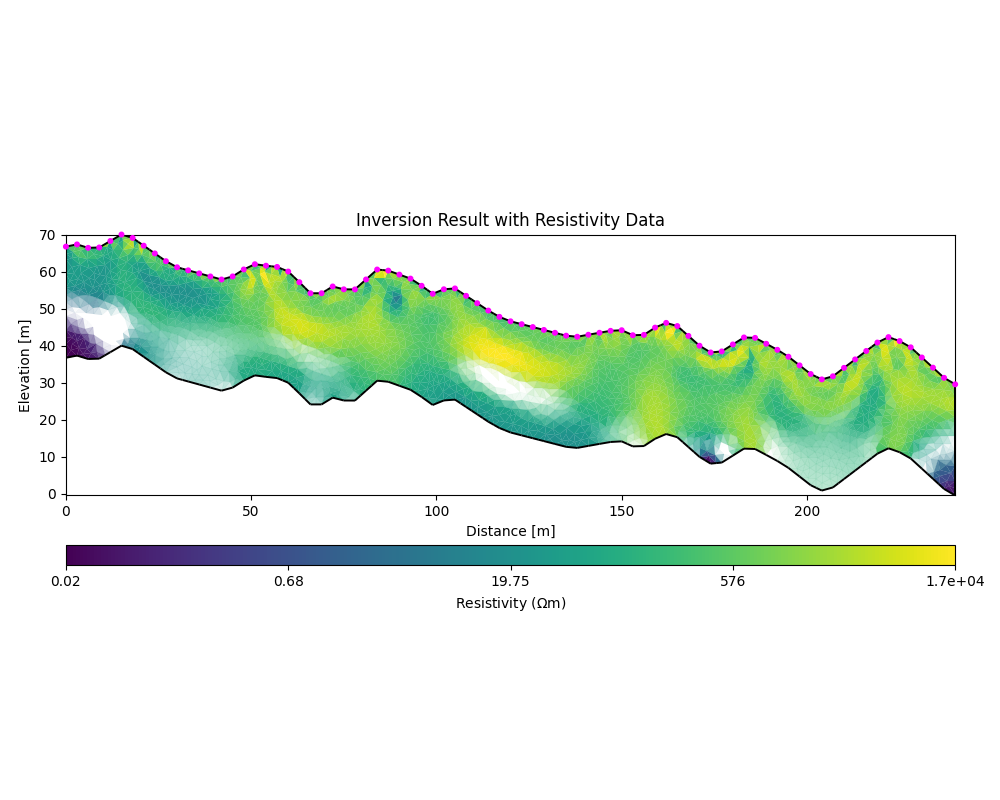

In [18]:
# initializing ERT manager
mgr = ert.ERTManager(data)

mgr.setMesh(mesh)

os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas\pygimex\ert\extra_files\line02')
print(f'Directory: {os.getcwd()}')

# mod = mgr.invert(data, lam=10, verbose=True,
#                  paraDX=0.3, paraMaxCellSize=10, paraDepth=30, quality=32)
mod = mgr.invert(data, lam=10, verbose=True, quality=32)

os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')

fig, ax = plt.subplots(figsize=(10, 8))
ax, cb = mgr.showResult(ax=ax, cMap='viridis', logScale=True)

ax.set_title("Inversion Result with Resistivity Data")
ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")

fig.savefig(r"figures\line02\ball_grad_A\5inversion_result.png", dpi=300, bbox_inches="tight")

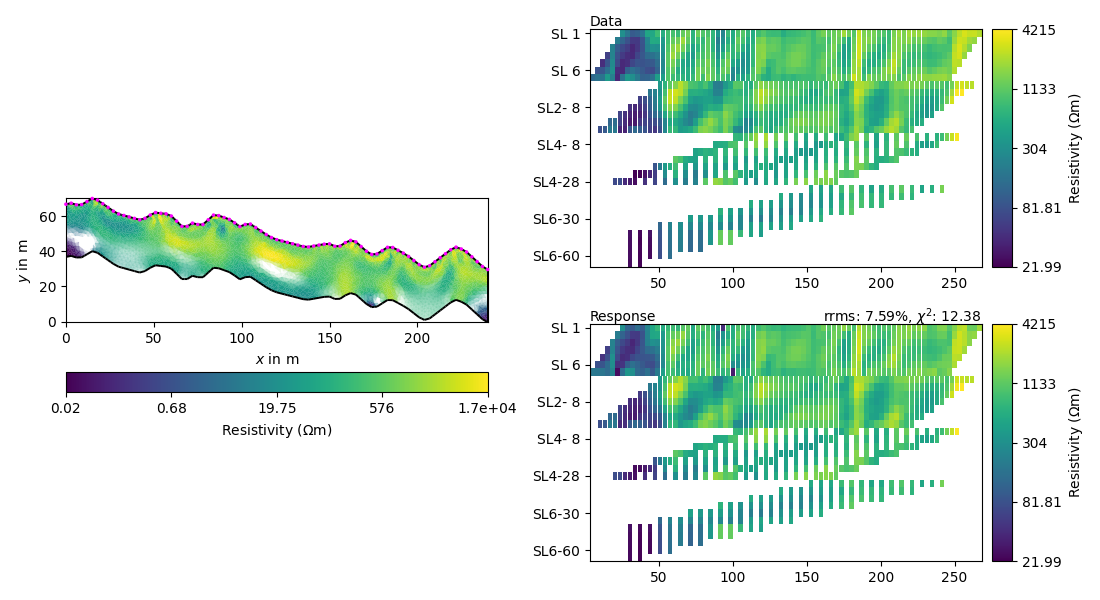

In [19]:
ax = mgr.showResultAndFit(cMap = 'viridis')
fig = ax.figure

fig.savefig(r'figures\line02\ball_grad_A\6inver_data_response.png',dpi=300,bbox_inches="tight")

from chat:

**cov**: computes coverage for each cell.
- high value → cell is well constrained by data.

**model**: resistivity value for each cell in the mesh.

**model_mask**: if a cell has zero coverage, replace its resistivity with NaN.

dont need both cov and mask.

0.03916942755375039
16642.785186784327


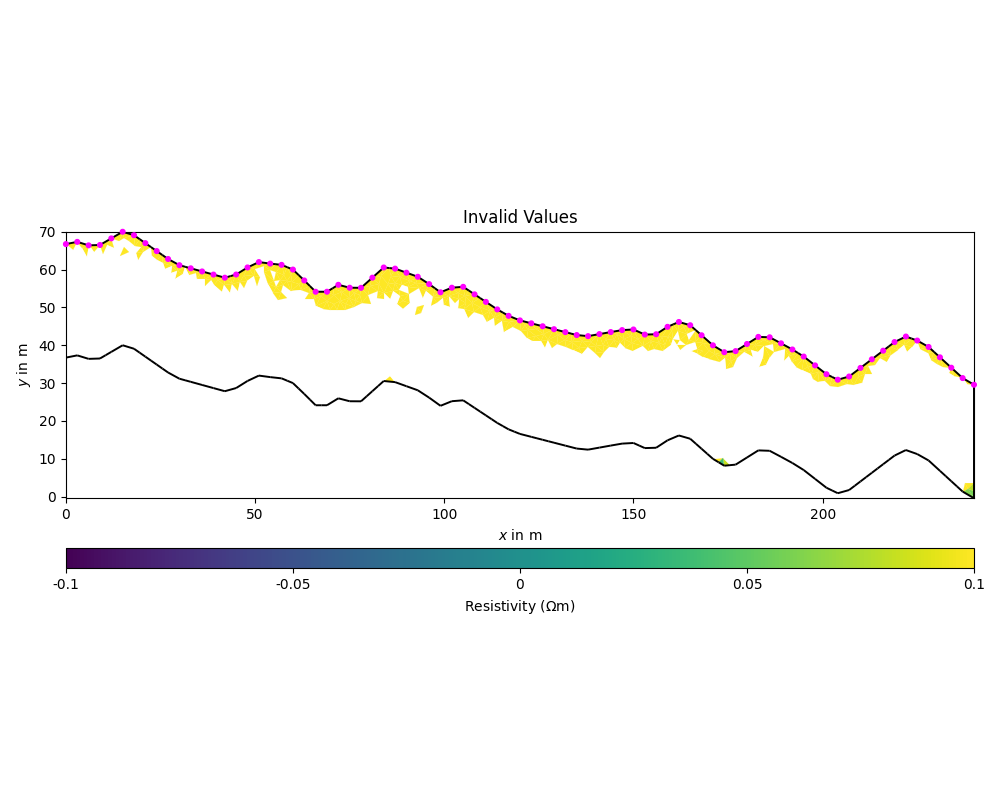

In [20]:
cov = mgr.standardizedCoverage()
model = mgr.inv.model
model_mask = model.copy()
model_mask[cov == 0] = np.nan 

print(np.nanmin(model_mask))
print(np.nanmax(model_mask))

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Invalid Values')
ax, cb = mgr.showResult(model=model_mask, ax=ax, cMap='viridis', logScale=False)

fig.savefig(r"figures\line02\ball_grad_A\7bad_pnts.png",dpi=300,bbox_inches="tight")

now we plot the points that are valid

[False False False ...  True  True  True]
Good data: 12.1866%


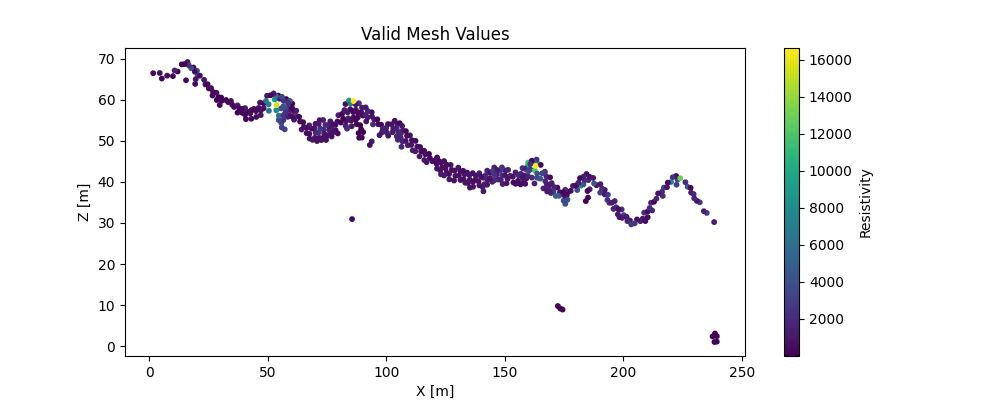

In [21]:
# mask of valid points
valid_mask = ~np.isnan(model_mask)

print(valid_mask)

total_cells = len(model_mask)
good_cells = np.sum(valid_mask)

percent_good = (good_cells / total_cells) * 100
print(f'Good data: {percent_good:.4f}%')

# indices
values_MM = model_mask[valid_mask]

# get mesh coordinates of elec and z cells
coords = np.array(mesh.cellCenters())

x_valid = coords[valid_mask, 0]
z_valid = coords[valid_mask, 1]

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(x_valid, z_valid, c=values_MM, cmap='viridis', s=10)
ax.set_xlabel("X [m]")
ax.set_ylabel("Z [m]")
ax.set_title("Valid Mesh Values")
plt.colorbar(ax.collections[0], ax=ax, label='Resistivity')

fig.savefig(r'figures/line02/ball_grad_A/8mesh_pnts.png', dpi=300, bbox_inches='tight')

plt.show()